# Séance 5 — Variables temporelles

**Durée pratique : 2 h** &nbsp;·&nbsp; Ateliers 5.1 à 5.3

## Ce que vous saurez faire à la fin

- parser des dates hétérogènes sans perdre de lignes silencieusement ;
- extraire des variables calendaires exploitables en analyse et en BI ;
- rééchantillonner une série et calculer des moyennes mobiles.

> **Convention de nommage du module.** Le code est écrit en anglais et suit la PEP 8 :
> fonctions et variables en `snake_case`, constantes en `MAJUSCULES`. Les **noms de colonnes**
> restent en français parce qu'ils viennent de la source : renommer les colonnes d'un fichier
> d'entrée est une transformation comme une autre, elle se décide et se documente, elle ne se
> fait pas par réflexe. Vous rencontrerez cette situation partout en entreprise.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)

print('Données disponibles :')
for path in sorted(RAW_DIR.glob('*')):
    print(' ', path.name)


# Parquet conserve les types (dates, entiers, catégories) là où le CSV les perd :
# c'est le format à privilégier entre deux étapes d'un pipeline. Repli automatique
# sur le CSV si pyarrow n'est pas installé.
def save_dataset(df, name):
    try:
        path = PROCESSED_DIR / f'{name}.parquet'
        df.to_parquet(path, index=False)
    except ImportError:
        path = PROCESSED_DIR / f'{name}.csv'
        df.to_csv(path, index=False)
        print('(pyarrow absent : repli sur le CSV)')
    print('écrit :', path.name, df.shape)
    return path


def load_dataset(name):
    parquet_path = PROCESSED_DIR / f'{name}.parquet'
    csv_path = PROCESSED_DIR / f'{name}.csv'
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    raise FileNotFoundError(f'{name} introuvable : exécutez le notebook précédent')


def dataset_exists(name):
    return ((PROCESSED_DIR / f'{name}.parquet').exists()
            or (PROCESSED_DIR / f'{name}.csv').exists())

Données disponibles :
  .gitkeep
  capteurs.csv
  clients.csv
  magasins.csv
  produits.csv
  ventes_brutes.csv
  ventes_extrait.json
  ventes_extrait.xlsx


---
## Atelier 5.1 — Parser des dates hétérogènes (35 min)

### Partie guidée

In [2]:
raw_sales = pd.read_csv(RAW_DIR / 'ventes_brutes.csv')
print(raw_sales['date_commande'].dropna().sample(10, random_state=1).tolist())

['2023-01-31', '15 Apr 2024', '07 Apr 2023', '2024/02/06 16:05', '2023/09/09 20:40', '2023-05-08', '08 Dec 2023', '07 Feb 2023', '01/11/2024', '06 Sep 2024']


Cinq formats coexistent dans la même colonne. Le piège est réel : `05/03/2024` peut se lire
5 mars ou 3 mai selon la convention. Une erreur ici déplace des milliers de lignes de mois
sans qu'aucune exception ne soit levée.

In [3]:
# format='mixed' laisse pandas inférer ligne par ligne ; dayfirst lève l'ambiguïté jj/mm
order_dates = pd.to_datetime(raw_sales['date_commande'],
                             format='mixed', dayfirst=True, errors='coerce')

n_missing_before = raw_sales['date_commande'].isna().sum()
n_missing_after = order_dates.isna().sum()

print('Valeurs initialement absentes  :', n_missing_before)
print('Valeurs absentes après parsing :', n_missing_after)
print('Échecs de conversion           :', n_missing_after - n_missing_before)
print('Plage couverte :', order_dates.min(), '->', order_dates.max())

Valeurs initialement absentes  : 350
Valeurs absentes après parsing : 350
Échecs de conversion           : 0
Plage couverte : 2023-01-01 00:00:00 -> 2024-12-30 17:10:00


**`errors='coerce'` transforme les échecs en `NaT` au lieu de lever une exception.** C'est
commode, mais dangereux si vous ne comptez pas les échecs juste après. Une conversion qui
détruit 8 % des dates sans le signaler est une bombe à retardement.

### Partie autonome

In [4]:
# Q1. Écrire une fonction parse_dates(series) qui renvoie (series_converties, report)
#     où report est un dict : n_total, n_already_missing, n_failed, success_rate,
#     min_date, max_date. Levez une ValueError si le taux de réussite est inférieur
#     à un seuil passé en paramètre (défaut 0,95).

# La fonction vit dans src/temporal.py (livrable de la séance).
import sys
sys.path.insert(0, str(ROOT / 'src'))

from temporal import parse_dates

order_dates_mixed = order_dates          # résultat de la cellule guidée (format='mixed')
order_dates, report = parse_dates(raw_sales['date_commande'])
for key, value in report.items():
    print(f'  {key:<18} {value}')

# Le seuil fonctionne-t-il ? Un jeu où deux dates sur trois sont illisibles doit être refusé.
try:
    parse_dates(pd.Series(['2024-01-15', 'n/a', 'hier']))
except ValueError as error:
    print('\nValueError levée comme prévu :', error)

# Comparaison avec la cellule guidée : format='mixed' + dayfirst=True
is_different = order_dates.notna() & (order_dates != order_dates_mixed)
print(f'\nDates différentes entre les deux méthodes : {is_different.sum()} '
      f'({is_different.mean():.1%} des lignes)')
print(pd.DataFrame({'texte brut': raw_sales.loc[is_different, 'date_commande'],
                    "format='mixed'": order_dates_mixed[is_different],
                    'formats explicites': order_dates[is_different]}).head(6).to_string())

  n_total            17609
  n_already_missing  350
  n_failed           0
  success_rate       1.0
  min_date           2023-01-01 00:00:00
  max_date           2024-12-30 17:10:00

ValueError levée comme prévu : Taux de conversion 33.3% inférieur au seuil 95% : 2 valeurs non reconnues

Dates différentes entre les deux méthodes : 2482 (14.1% des lignes)
          texte brut      format='mixed'  formats explicites
4         2024-11-02 2024-02-11 00:00:00 2024-11-02 00:00:00
5   2023/08/01 12:03 2023-01-08 12:03:00 2023-08-01 12:03:00
12        2023-03-09 2023-09-03 00:00:00 2023-03-09 00:00:00
30  2023/06/01 08:10 2023-01-06 08:10:00 2023-06-01 08:10:00
35        2023-04-08 2023-08-04 00:00:00 2023-04-08 00:00:00
39        2024-05-08 2024-08-05 00:00:00 2024-05-08 00:00:00


**Pourquoi cette réponse (Q1), et un piège dans la cellule guidée.**
`parse_dates` essaie les **cinq formats connus, un par un** (`%Y-%m-%d`, `%d/%m/%Y`…) : chaque valeur est lue selon
un format explicite, jamais devinée. Le rapport sépare les valeurs **déjà absentes** (350, présentes dans la source)
des **échecs de conversion** (0). Seuls les échecs comptent dans le taux de réussite : une absence d'origine n'est pas
une erreur de conversion. La `ValueError` transforme une conversion ratée en arrêt net du pipeline, au lieu d'une
perte silencieuse.

**La cellule guidée plus haut se trompe sur 14 % des dates, sans aucun message.** `format='mixed', dayfirst=True`
applique « le jour d'abord » à **toutes** les valeurs, y compris aux formats où l'année vient en premier :
`2024-11-02` (2 novembre) devient le **11 février**. Le compteur « Échecs de conversion : 0 » et la plage de dates
paraissent corrects : l'erreur est invisible. C'est exactement la « bombe à retardement » décrite dans le texte, et
la raison d'imposer les formats. Les ventes utilisées ensuite viennent de `clean_sales` (séance 3), qui lit déjà les
formats explicitement : elles ne sont pas touchées.

---
## Atelier 5.2 — Variables calendaires (45 min)

### Partie guidée

In [5]:
if dataset_exists('ventes_transformees'):
    sales = load_dataset('ventes_transformees')
else:
    sales = raw_sales.assign(date_commande=order_dates).dropna(subset=['date_commande'])

sales['date_commande'] = pd.to_datetime(sales['date_commande'], errors='coerce')
sales = sales.dropna(subset=['date_commande'])

date_accessor = sales['date_commande'].dt
sales['annee'] = date_accessor.year
sales['mois'] = date_accessor.month
sales['jour_semaine'] = date_accessor.dayofweek          # 0 = lundi
sales['nom_jour'] = date_accessor.day_name()
sales['semaine_iso'] = date_accessor.isocalendar().week.astype(int)
sales['trimestre'] = date_accessor.quarter
sales['heure'] = date_accessor.hour
sales['est_weekend'] = sales['jour_semaine'] >= 5

sales[['date_commande', 'annee', 'mois', 'nom_jour', 'semaine_iso', 'est_weekend']].head()

,date_commande,annee,mois,nom_jour,semaine_iso,est_weekend
0,2024-01-18 19:53:00,2024,1,Thursday,3,False
1,2024-01-08 00:00:00,2024,1,Monday,2,False
2,2023-04-15 00:00:00,2023,4,Saturday,15,True
3,2024-11-06 00:00:00,2024,11,Wednesday,45,False
4,2024-11-02 00:00:00,2024,11,Saturday,44,True


**`isocalendar().week` plutôt que `.week`.** La semaine ISO gère correctement les jours de
fin décembre appartenant à la semaine 1 de l'année suivante. C'est exactement le genre de
détail qui produit des écarts inexplicables entre deux tableaux de bord.

In [6]:
# Encodage cyclique : le mois 12 est adjacent au mois 1, ce qu'un entier ne dit pas
sales['mois_sin'] = np.sin(2 * np.pi * sales['mois'] / 12)
sales['mois_cos'] = np.cos(2 * np.pi * sales['mois'] / 12)

cyclic = sales.groupby('mois')[['mois_sin', 'mois_cos']].first().round(3)
print(cyclic)
print()
print('Distance entre décembre et janvier :',
      round(float(np.hypot(*(cyclic.loc[12] - cyclic.loc[1]))), 3))
print('Distance entre janvier et février  :',
      round(float(np.hypot(*(cyclic.loc[1] - cyclic.loc[2]))), 3))

      mois_sin  mois_cos
mois                    
1        0.500     0.866
2        0.866     0.500
3        1.000     0.000
4        0.866    -0.500
5        0.500    -0.866
6        0.000    -1.000
7       -0.500    -0.866
8       -0.866    -0.500
9       -1.000    -0.000
10      -0.866     0.500
11      -0.500     0.866
12      -0.000     1.000

Distance entre décembre et janvier : 0.518
Distance entre janvier et février  : 0.518


### Partie autonome

In [7]:
# Q2. Ajouter les variables suivantes :
#     - periode_journee : 'matin' (<12), 'apres-midi' (12-17), 'soir' (>=18) ;
#     - est_fin_de_mois : les trois derniers jours du mois ;
#     - jours_depuis_debut : nombre de jours écoulés depuis la première commande ;
#     - anciennete_client_jours : écart entre la date de commande et la date d'inscription
#       du client (nécessite une jointure avec clients.csv).

# periode_journee. Quatre formats de date sur cinq n'ont pas d'heure : pandas met alors
# 00:00. Aucune boutique ne vend à minuit (les heures réelles vont de 8 h à 20 h) :
# 00:00 signifie "heure inconnue", et ne doit surtout pas être classé en 'matin'.
has_time = ~((sales['heure'] == 0) & (sales['date_commande'].dt.minute == 0))
period = pd.cut(sales['heure'], bins=[0, 12, 18, 24], right=False,
                labels=['matin', 'apres-midi', 'soir'])
sales['periode_journee'] = period.where(has_time)

# est_fin_de_mois : jour du mois parmi les trois derniers (28-30-31 selon le mois)
sales['est_fin_de_mois'] = date_accessor.day > date_accessor.days_in_month - 3

# jours_depuis_debut : un compteur continu, utile pour mesurer une tendance
sales['jours_depuis_debut'] = (sales['date_commande'] - sales['date_commande'].min()).dt.days

# anciennete_client_jours : jointure avec le référentiel clients
customers = pd.read_csv(RAW_DIR / 'clients.csv', parse_dates=['date_inscription'])
registration = sales[['id_client']].merge(customers[['id_client', 'date_inscription']],
                                          on='id_client', how='left', validate='many_to_one')
sales['anciennete_client_jours'] = (
    sales['date_commande'].values - registration['date_inscription'].values
).astype('timedelta64[D]').astype(float)

print('periode_journee :')
print(sales['periode_journee'].value_counts(dropna=False).to_string())
print(f"\nest_fin_de_mois    : {sales['est_fin_de_mois'].mean():.1%} des commandes")
print('jours_depuis_debut :', sales['jours_depuis_debut'].min(), '->', sales['jours_depuis_debut'].max())
print('anciennete_client_jours :')
print(sales['anciennete_client_jours'].describe().round(1).to_string())
print('Commandes antérieures à l\'inscription :', (sales['anciennete_client_jours'] < 0).sum(),
      f"({(sales['anciennete_client_jours'] < 0).mean():.1%})")

periode_journee :
periode_journee
NaN           13546
apres-midi     1570
matin          1048
soir            828

est_fin_de_mois    : 9.2% des commandes
jours_depuis_debut : 0 -> 729
anciennete_client_jours :
count    16992.0
mean       845.6
std        622.0
min       -508.0
25%        340.0
50%        864.0
75%       1356.0
max       2188.0
Commandes antérieures à l'inscription : 1740 (10.2%)


**Pourquoi ces choix (Q2).**
- **`periode_journee` : l'heure 00:00 est traitée comme inconnue.** Seules 20 % des dates ont une heure (format
  `2024/02/06 16:05`). Pour les autres, pandas met minuit. Sans précaution, 80 % des commandes seraient classées
  « matin », un artefact complet. `pd.cut` avec `right=False` découpe [0 ; 12[, [12 ; 18[, [18 ; 24[, ce qui
  respecte l'énoncé (18 h = soir).
- **`est_fin_de_mois` utilise `days_in_month`** : les « trois derniers jours » sont 26-28 en février et 29-31 en
  janvier. Un seuil fixe (jour ≥ 28) serait faux la plupart des mois.
- **`jours_depuis_debut`** transforme la date en compteur continu, ce qu'un modèle ou une régression de tendance sait
  exploiter.
- **`anciennete_client_jours` : jointure `validate='many_to_one'`**, qui garantit qu'un client n'apparaît qu'une fois
  dans le référentiel. **Anomalie découverte** : 10 % des commandes sont **antérieures** à l'inscription du client.
  Deux explications sont possibles : une commande passée en invité avant la création du compte, ou une date
  d'inscription erronée. On garde la valeur négative, car elle porte l'information, mais c'est une question à poser
  au métier avant toute analyse d'ancienneté.

In [8]:
# Q3. Le chiffre d'affaires est-il différent le week-end ? Comparez le montant moyen
#     par commande selon est_weekend, puis selon le nom du jour. Commentez.

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
normal_orders = sales[~sales['quantite_suspecte']]

by_weekend = pd.DataFrame({
    'moyenne (toutes)': sales.groupby('est_weekend')['montant'].mean(),
    'médiane (toutes)': sales.groupby('est_weekend')['montant'].median(),
    'moyenne (hors suspectes)': normal_orders.groupby('est_weekend')['montant'].mean(),
    'commandes': sales.groupby('est_weekend').size(),
}).round(1)
by_weekend.index = by_weekend.index.map({False: 'semaine', True: 'week-end'})
print(by_weekend.to_string())

print()
by_day = pd.DataFrame({
    'moyenne (toutes)': sales.groupby('nom_jour')['montant'].mean(),
    'médiane (toutes)': sales.groupby('nom_jour')['montant'].median(),
    'moyenne (hors suspectes)': normal_orders.groupby('nom_jour')['montant'].mean(),
}).reindex(DAY_ORDER).round(1)
print(by_day.to_string())

print()
print(f"Part du week-end : {sales['est_weekend'].mean():.1%} des commandes, "
      f"{sales.loc[sales['quantite_suspecte'], 'est_weekend'].mean():.1%} des quantités suspectes")

# Commentaire : la moyenne semble 60 % plus élevée le week-end (3 453 contre 2 143 EUR),
# mais la médiane est identique (971 contre 958) et, sans les quantités suspectes de la
# séance 3, les moyennes redeviennent égales (1 244 contre 1 217). L'écart ne vient donc pas
# du comportement des clients : les quantités suspectes sont sur-représentées le week-end
# (42 % d'entre elles pour 28 % des commandes). Il n'y a PAS d'effet week-end réel ; en
# revanche, les erreurs de saisie se concentrent le week-end, une piste à remonter au métier.

             moyenne (toutes)  médiane (toutes)  moyenne (hors suspectes)  commandes
est_weekend                                                                         
semaine                2142.9             958.1                    1216.7      12180
week-end               3453.0             971.0                    1243.8       4812

           moyenne (toutes)  médiane (toutes)  moyenne (hors suspectes)
nom_jour                                                               
Monday               1938.6             964.2                    1191.9
Tuesday              1943.6             945.8                    1217.3
Wednesday            2455.7             928.6                    1205.4
Thursday             2291.2             956.3                    1214.5
Friday               2102.2             996.7                    1253.9
Saturday             3176.5             963.8                    1249.0
Sunday               3723.5             974.2                    1238.8

Part du we

**Pourquoi cette réponse (Q3).**
On compare la **moyenne**, la **médiane**, puis la moyenne **sans les quantités suspectes**. Trois mesures, parce qu'une
moyenne seule est tirée par les valeurs extrêmes.
- **La moyenne suggère un fort effet week-end** (+60 %, et le dimanche est le jour le plus élevé).
- **La médiane le dément** : la commande typique vaut environ 960 € tous les jours.
- **Sans les commandes suspectes, l'écart disparaît** (1 244 € contre 1 217 €).

**Conclusion :** le comportement d'achat ne change pas le week-end. Ce sont les **erreurs de saisie** qui y sont plus
fréquentes : 42 % des quantités suspectes pour 28 % des commandes. C'est un résultat utile, qui renvoie à la séance 3 :
sans l'indicateur `quantite_suspecte`, on aurait présenté un faux effet week-end.

---
## Atelier 5.3 — Rééchantillonnage et fenêtres glissantes (40 min)

Le jeu `capteurs.csv` contient trois séries horaires sur dix-huit mois, avec une panne de
onze jours, un capteur bloqué sur une valeur constante et des horodatages dupliqués.

In [9]:
sensors = pd.read_csv(RAW_DIR / 'capteurs.csv', parse_dates=['horodatage'])

print(sensors.shape)
print(sensors['id_capteur'].value_counts())
print('Doublons (capteur, horodatage) :',
      sensors.duplicated(['id_capteur', 'horodatage']).sum())

(38916, 5)
id_capteur
CAP-C    13070
CAP-A    13069
CAP-B    12777
Name: count, dtype: int64
Doublons (capteur, horodatage) : 300


In [10]:
# Nettoyage minimal avant toute analyse temporelle
sensors = sensors.drop_duplicates(['id_capteur', 'horodatage'])
sensors['humidite_pct'] = sensors['humidite_pct'].replace(-999, np.nan)

sensor_a = (sensors[sensors['id_capteur'] == 'CAP-A']
            .set_index('horodatage')
            .sort_index())

daily_temperature = sensor_a['temperature_c'].resample('D').mean()
print(daily_temperature.head())
print('\nJours sans aucune mesure :', daily_temperature.isna().sum())

horodatage
2024-01-01    3.515000
2024-01-02    3.279130
2024-01-03    2.618261
2024-01-04    2.894348
2024-01-05    3.340435
Freq: D, Name: temperature_c, dtype: float64

Jours sans aucune mesure : 0


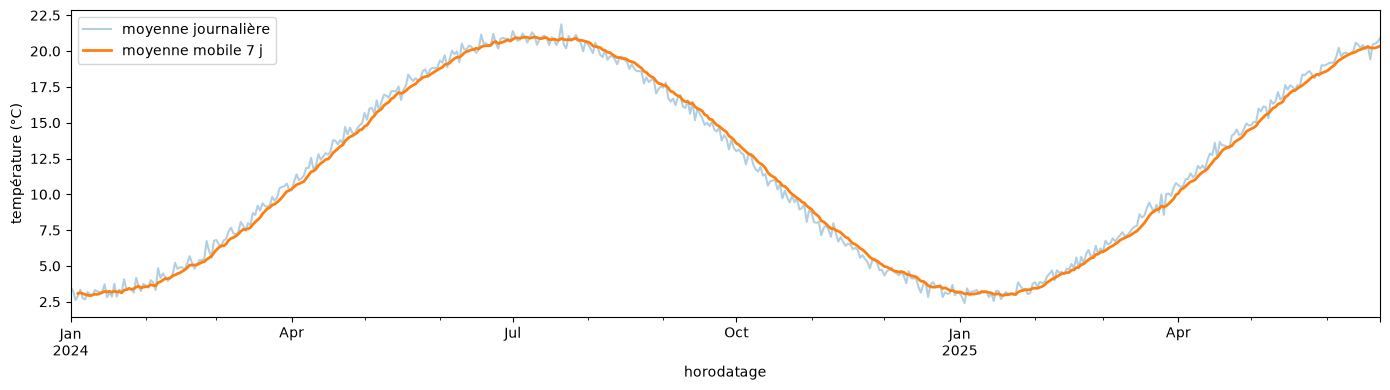

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 4))
daily_temperature.plot(ax=ax, alpha=0.35, label='moyenne journalière')
(daily_temperature.rolling(7, min_periods=4).mean()
 .plot(ax=ax, linewidth=2, label='moyenne mobile 7 j'))
ax.set_ylabel('température (°C)')
ax.legend()
plt.tight_layout()
plt.show()

`min_periods=4` autorise le calcul dès le quatrième point disponible, au lieu d'attendre
sept valeurs complètes. Sans cela, chaque trou de la série efface les six points suivants
de la courbe lissée.

### Partie autonome

In [12]:
# Q4. Détecter automatiquement la panne du capteur CAP-B :
#     trouver les plages horaires sans aucune mesure de plus de 24 heures.
#     Indice : réindexer sur une plage horaire complète puis repérer les suites de NaN.

from temporal import find_gaps

for sensor_id, readings in sensors.groupby('id_capteur'):
    gaps = find_gaps(readings['horodatage'], freq='h', min_missing=24)
    print(f'{sensor_id} : {len(gaps)} panne(s) de plus de 24 h')
    if len(gaps):
        print(gaps.to_string(index=False))

CAP-A : 0 panne(s) de plus de 24 h
CAP-B : 1 panne(s) de plus de 24 h
     debut                 fin  periodes_manquantes   duree
2024-06-03 2024-06-13 23:00:00                  264 11 days
CAP-C : 0 panne(s) de plus de 24 h


**Pourquoi cette réponse (Q4).**
Une panne **ne laisse pas de NaN** : les lignes n'existent tout simplement pas. `find_gaps` crée donc la grille
complète attendue (une ligne par heure, du premier au dernier relevé), et les heures absentes y deviennent des `NaN`.
On numérote ensuite les blocs consécutifs : `(is_missing != is_missing.shift()).cumsum()` change de numéro à chaque
passage de présent à absent, ce qui permet de mesurer chaque bloc.

**Résultat :** CAP-B n'a rien mesuré **du 3 au 13 juin 2024 inclus**, soit 264 heures (11 jours), la panne annoncée
dans l'énoncé. CAP-A et CAP-C n'ont aucun trou : la fonction ne donne pas de fausse alerte. Les doublons
d'horodatage ont été supprimés avant (cellule guidée), sinon `reindex` échouerait sur un index non unique.

In [13]:
# Q5. Détecter le capteur bloqué : trouver la période où CAP-C renvoie une valeur
#     strictement constante pendant plus de 24 relevés consécutifs.
#     Un capteur bloqué ne produit pas de valeur manquante : c'est ce qui rend
#     cette anomalie difficile à repérer et coûteuse à laisser passer.

from temporal import find_stuck_values

MEASURES = ['temperature_c', 'humidite_pct', 'pm25']

# On balaie les trois capteurs et les trois mesures : la fonction ne doit signaler
# QUE le vrai blocage, sans fausses alertes sur les séries saines.
for sensor_id, readings in sensors.groupby('id_capteur'):
    series_by_time = readings.set_index('horodatage').sort_index()
    for measure in MEASURES:
        stuck = find_stuck_values(series_by_time[measure], min_length=24)
        if len(stuck):
            print(f'{sensor_id} / {measure} :')
            print(stuck.to_string(index=False))
print('(aucune autre série bloquée)')

# Pourquoi retirer les NaN d'abord : sans cela, un relevé manquant coupe le blocage en deux
cap_c = sensors[sensors['id_capteur'] == 'CAP-C'].set_index('horodatage').sort_index()['temperature_c']
naive_blocks = (cap_c != cap_c.shift()).cumsum()
naive_lengths = cap_c.groupby(naive_blocks).size()
print('\nSans retirer les NaN, le blocage apparaît en morceaux de :',
      sorted(naive_lengths[naive_lengths > 24].tolist(), reverse=True), 'relevés')

CAP-C / temperature_c :
              debut                 fin  releves  valeur
2024-09-10 01:00:00 2024-09-14 23:00:00      117    17.4


(aucune autre série bloquée)

Sans retirer les NaN, le blocage apparaît en morceaux de : [53, 51] relevés


**Pourquoi cette réponse (Q5).**
Un capteur bloqué renvoie des valeurs **plausibles** (17,4 °C), donc aucun contrôle de valeur manquante ou de valeur
aberrante ne le voit. On cherche plutôt des **suites de valeurs identiques** : même technique de numérotation des
blocs qu'en Q4, appliquée aux changements de valeur.

**Résultat :** CAP-C reste figé à **17,4 °C du 10 septembre 2024 à 1 h au 14 septembre à 23 h**, soit 117 relevés
consécutifs. Aucune des 8 autres séries n'est signalée : pas de fausse alerte.

**Le détail qui compte : retirer les NaN d'abord.** Quelques relevés manquent pendant le blocage. Comme `NaN != 17,4`,
chaque trou démarre un nouveau bloc : sans `dropna`, le blocage apparaît en plusieurs morceaux plus courts. Avec un
seuil plus élevé, il passerait même sous le radar. Un capteur bloqué reste bloqué, qu'un relevé manque ou non.

106 semaines | CA hebdomadaire médian : 195 529 EUR

               CA (k EUR)  commandes  panier_moyen
date_commande                                     
2023-01-01          823.4      724.0        1137.3
2023-02-01          785.6      686.0        1145.2
2023-03-01          800.9      724.0        1106.2
2023-04-01          835.6      706.0        1183.6
2023-05-01          871.3      749.0        1163.2
2023-06-01          803.7      720.0        1116.2
2023-07-01          855.3      750.0        1140.4
2023-08-01          554.8      480.0        1155.9
2023-09-01          849.8      742.0        1145.3
2023-10-01          830.2      705.0        1177.5
2023-11-01         1140.1      737.0        1546.9
2023-12-01         1103.6      714.0        1545.7
2024-01-01          866.5      730.0        1186.9
2024-02-01          815.8      693.0        1177.3
2024-03-01          872.9      735.0        1187.6
2024-04-01          843.2      734.0        1148.8
2024-05-01          853.3    

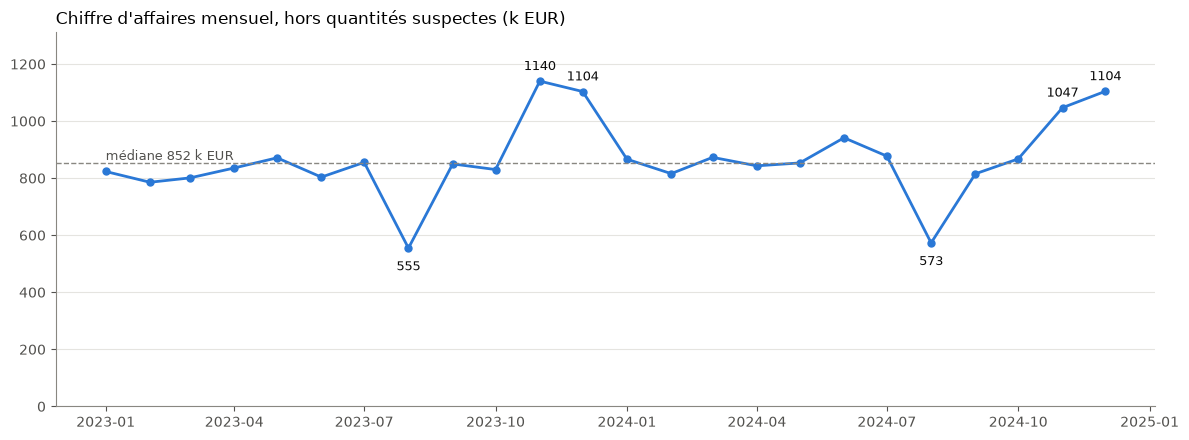

In [14]:
# Q6. Agréger les ventes par semaine puis par mois. Tracer la série mensuelle du
#     chiffre d'affaires et commenter la saisonnalité observée.

import matplotlib.pyplot as plt

# Les quantités suspectes (séance 3) portent la moitié du CA : elles noieraient la saisonnalité.
by_date = sales[~sales['quantite_suspecte']].set_index('date_commande').sort_index()

weekly = by_date['montant'].resample('W').agg(['sum', 'size'])
weekly.columns = ['chiffre_affaires', 'commandes']
monthly = by_date['montant'].resample('MS').agg(['sum', 'size'])
monthly.columns = ['chiffre_affaires', 'commandes']
monthly['panier_moyen'] = monthly['chiffre_affaires'] / monthly['commandes']

print(f'{len(weekly)} semaines | CA hebdomadaire médian : {weekly["chiffre_affaires"].median():,.0f} EUR'
      .replace(',', ' '))
print()
print((monthly / [1000, 1, 1]).round(1).rename(columns={'chiffre_affaires': 'CA (k EUR)'}).to_string())

# Graphique : une seule série, donc pas de légende ; seuls les points commentés sont étiquetés.
revenue_k = monthly['chiffre_affaires'] / 1000
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(revenue_k.index, revenue_k.values, color='#2a78d6', linewidth=2,
        marker='o', markersize=5)
ax.axhline(revenue_k.median(), color='#898781', linewidth=1, linestyle='--')
ax.text(revenue_k.index[0], revenue_k.median() + 12, f'médiane {revenue_k.median():.0f} k EUR',
        color='#52514e', fontsize=9)
for moment, value in revenue_k.items():
    if moment.month in (8, 11, 12):
        ax.annotate(f'{value:.0f}', (moment, value), textcoords='offset points',
                    xytext=(0, 8 if moment.month != 8 else -16), ha='center',
                    color='#0b0b0b', fontsize=9)
ax.set_title("Chiffre d'affaires mensuel, hors quantités suspectes (k EUR)", loc='left')
ax.set_ylim(0, revenue_k.max() * 1.15)
ax.grid(axis='y', color='#e5e4e0', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#898781')
ax.tick_params(colors='#52514e')
plt.tight_layout()
plt.show()

**Pourquoi cette réponse (Q6), et lecture de la saisonnalité.**
`resample('W')` et `resample('MS')` regroupent par semaine et par mois civil ; il faut pour cela que la date soit en
**index**. On exclut les quantités suspectes, sinon **une seule** commande de 1 000 unités suffit à doubler le
chiffre d'affaires d'un mois : la série devient illisible et la saisonnalité disparaît.

**Ce que montre le graphique, identique les deux années :**
- **Un niveau stable** d'environ 850 k€ par mois (médiane : 852 k€), de janvier à juillet et en septembre-octobre.
- **Un creux en août** (environ un tiers de moins, 555 et 573 k€). Il vient du **nombre de commandes** (480 au lieu de 720) : c'est l'effet
  des congés d'été.
- **Un pic en novembre-décembre** (+25 à +35 %, de 1 047 à 1 140 k€). Le nombre de commandes ne change pas (environ 720), c'est
  le **panier moyen** qui augmente (environ 1 550 € au lieu de 1 150 €) : Black Friday et achats de Noël, avec des
  produits plus chers.

**En pratique :** on ne compare jamais août ou décembre à la moyenne annuelle, mais au même mois de l'année
précédente.

In [15]:
# Export du jeu de ventes enrichi de ses variables temporelles (livrable de la séance).
save_dataset(sales, 'ventes_temporelles')

écrit : ventes_temporelles.parquet (16992, 37)


WindowsPath('C:/Users/loicn/Desktop/TP manipulation de données/data/processed/ventes_temporelles.parquet')

---
## Livrable de la séance

- la fonction `parse_dates` avec son rapport de conversion, dans `src/` ;
- le jeu de ventes enrichi de ses variables temporelles ;
- les deux fonctions de détection d'anomalies de capteur (panne et blocage) ;
- un graphique commenté de la saisonnalité mensuelle.